# Performance Metrics for a Buy-and-Hold Strategy

A **buy-and-hold strategy** is one of the simplest investment benchmarks. We buy an asset once, hold it through time, and measure how the investment performed.

Performance metrics matter because the final return alone does not tell the full story. Two strategies may have the same total return, but one may have much larger day-to-day swings, deeper losses, or more painful drawdowns.

In this notebook, we evaluate a simple buy-and-hold investment using daily returns, cumulative returns, annualized return, annualized risk, and maximum drawdown.

## 1. Imports

We use only `pandas`, `numpy`, and `matplotlib` for this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.6f}'.format
plt.style.use('default')

## 2. Create or Use a Price DataFrame

This notebook expects a DataFrame called `df` with a `price` column.

If `df` already exists, the notebook uses it. If no dataset is provided, we generate a realistic synthetic daily price series so the notebook runs from top to bottom.

In [2]:
if 'df' not in globals():
    # Reproducible example data: daily business-day prices with mild drift and volatility.
    rng = np.random.default_rng(42)
    dates = pd.bdate_range(start='2020-01-02', end='2024-12-31')
    daily_returns_example = rng.normal(loc=0.00035, scale=0.012, size=len(dates))
    synthetic_price = 100 * np.cumprod(1 + daily_returns_example)

    df = pd.DataFrame({'price': synthetic_price}, index=dates)
    df.index.name = 'Date'
    data_source = 'Synthetic example price data'
else:
    data_source = 'Existing df from notebook environment'

# Basic safety checks and cleanup.
if 'price' not in df.columns:
    raise ValueError("df must contain a column named 'price'.")

df = df.copy()
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])

print(f'Data source: {data_source}')
print(f'Date range: {df.index.min().date()} to {df.index.max().date()}')
print(f'Rows: {len(df):,}')

df.head()

Data source: Synthetic example price data
Date range: 2020-01-02 to 2024-12-31
Rows: 1,304


,price
Date,
2020-01-02,100.400660
2020-01-03,99.182820
2020-01-06,100.110716
2020-01-07,101.275682
2020-01-08,98.940019


## 3. Calculate Daily Returns and Cumulative Returns

Daily simple returns measure the percentage change from one price to the next.

The cumulative return series shows the growth of an initial investment of `1.0`. This is often called a **growth-of-1** series.

In [3]:
# Daily simple returns.
df['daily_return'] = df['price'].pct_change(fill_method=None)

# Growth of $1 invested. Fill the first missing return with 0 so the series starts at 1.
df['cumulative_return'] = (1 + df['daily_return'].fillna(0)).cumprod()

ending_value = df['cumulative_return'].iloc[-1]
total_return = ending_value - 1

print(f'Ending value of $1 invested: ${ending_value:.4f}')
print(f'Total cumulative return:     {total_return:.2%}')

df.head()

Ending value of $1 invested: $0.9525
Total cumulative return:     -4.75%


,price,daily_return,cumulative_return
Date,,,
2020-01-02,100.400660,NaN,1.000000
2020-01-03,99.182820,-0.012130,0.987870
2020-01-06,100.110716,0.009355,0.997112
2020-01-07,101.275682,0.011637,1.008715
2020-01-08,98.940019,-0.023062,0.985452


Absolute performance can be expressed in two equivalent ways:

- **Final value of $1 invested:** if this is `1.25`, then $1 grew to $1.25.
- **Total cumulative return:** if the final value is `1.25`, then the total return is `25%`.

Both describe the same result, just in different formats.

## 4. Return Summary Statistics

The average daily return gives a simple estimate of reward. The standard deviation of daily returns gives a basic estimate of risk or volatility.

In [4]:
returns = df['daily_return'].dropna()

mean_daily_return = returns.mean()
std_daily_return = returns.std()

print(f'Mean daily return:             {mean_daily_return:.6f}')
print(f'Standard deviation of returns: {std_daily_return:.6f}')

Mean daily return:             0.000033
Standard deviation of returns: 0.011874


## 5. Annualize Return and Risk

Daily metrics are useful, but they can be hard to interpret. We often annualize them using `252` trading days per year.

- Annualized mean return = daily mean return x `252`
- Annualized volatility = daily standard deviation x square root of `252`

In [5]:
trading_days_per_year = 252

annualized_return = mean_daily_return * trading_days_per_year
annualized_volatility = std_daily_return * np.sqrt(trading_days_per_year)

print(f'Annualized return:     {annualized_return:.2%}')
print(f'Annualized volatility: {annualized_volatility:.2%}')

Annualized return:     0.83%
Annualized volatility: 18.85%


## 6. Mean-Variance Framework

The **mean-variance framework** compares investments using expected return and volatility.

- Expected return is often estimated with the average return.
- Volatility is often estimated with the standard deviation of returns.

This framework is useful because it gives us a simple way to compare reward and risk. However, it has limitations. Financial returns are often not perfectly normally distributed, and extreme downside events may not be fully captured by mean and standard deviation alone.

That is why we also look at drawdown.

## 7. Calculate Maximum Drawdown

A **drawdown** measures how far the investment has fallen from its previous peak.

Maximum drawdown is the largest peak-to-trough decline in the sample. It is useful because it describes the pain of holding through losses, not just the final return.

In [6]:
# Running peak of the growth-of-1 series.
df['cumulative_max'] = df['cumulative_return'].cummax()

# Drawdown as a positive distance from the running peak.
df['drawdown'] = (df['cumulative_max'] - df['cumulative_return']) / df['cumulative_max']

maximum_drawdown = df['drawdown'].max()
maximum_drawdown_date = df['drawdown'].idxmax()

print(f'Maximum drawdown:      {maximum_drawdown:.2%}')
print(f'Maximum drawdown date: {maximum_drawdown_date.date()}')

df[['price', 'cumulative_return', 'cumulative_max', 'drawdown']].head()

Maximum drawdown:      31.67%
Maximum drawdown date: 2022-11-08


,price,cumulative_return,cumulative_max,drawdown
Date,,,,
2020-01-02,100.400660,1.000000,1.000000,0.000000
2020-01-03,99.182820,0.987870,1.000000,0.012130
2020-01-06,100.110716,0.997112,1.000000,0.002888
2020-01-07,101.275682,1.008715,1.008715,0.000000
2020-01-08,98.940019,0.985452,1.008715,0.023062


## 8. Visualize the Strategy

Charts make the metrics easier to understand. We will plot:

- the price series
- cumulative returns compared with the cumulative maximum
- drawdown over time

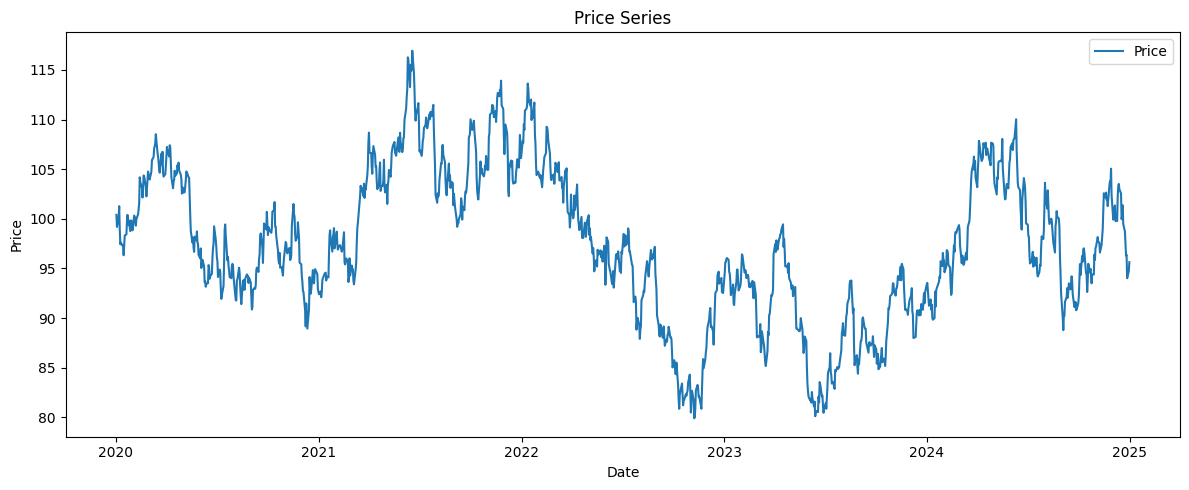

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['price'], label='Price')
plt.title('Price Series')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

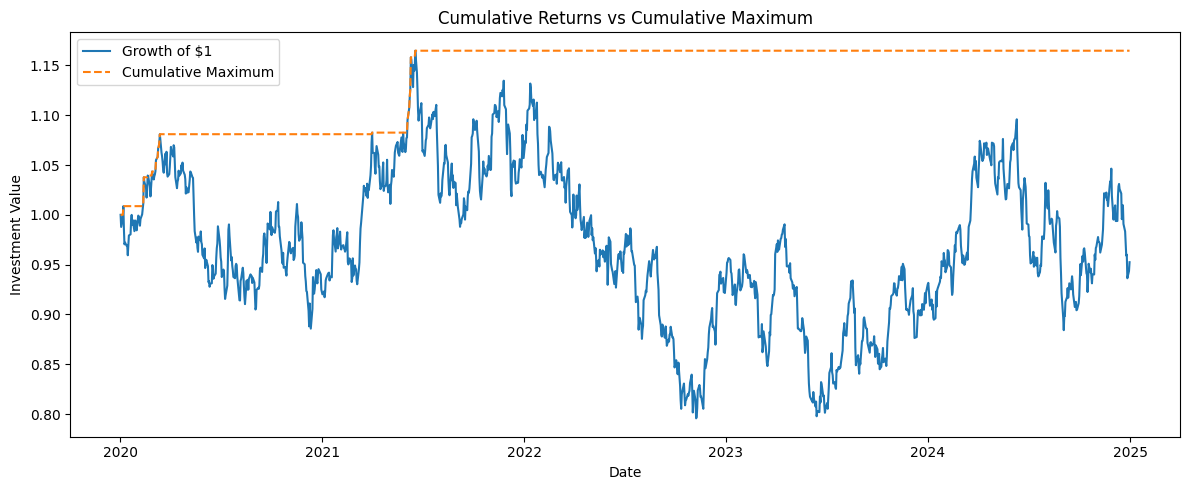

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['cumulative_return'], label='Growth of $1')
plt.plot(df.index, df['cumulative_max'], label='Cumulative Maximum', linestyle='--')
plt.title('Cumulative Returns vs Cumulative Maximum')
plt.xlabel('Date')
plt.ylabel('Investment Value')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['drawdown'], label='Drawdown')
plt.title('Drawdown Over Time')
plt.xlabel('Date')
plt.ylabel('Drawdown')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Clearly Formatted Performance Outputs

Now we print the key metrics together so they are easy to read.

In [9]:
print('Buy-and-Hold Performance Metrics')
print('-' * 40)
print(f'Ending value of $1 invested: ${ending_value:.4f}')
print(f'Total return:                 {total_return:.2%}')
print(f'Annualized return:            {annualized_return:.2%}')
print(f'Annualized volatility:        {annualized_volatility:.2%}')
print(f'Maximum drawdown:             {maximum_drawdown:.2%}')
print(f'Maximum drawdown date:        {maximum_drawdown_date.date()}')

Buy-and-Hold Performance Metrics
----------------------------------------
Ending value of $1 invested: $0.9525
Total return:                 -4.75%
Annualized return:            0.83%
Annualized volatility:        18.85%
Maximum drawdown:             31.67%
Maximum drawdown date:        2022-11-08


## 10. Helper Summary Table

A compact metrics table is useful when comparing multiple strategies later. For now, it summarizes the buy-and-hold benchmark.

In [10]:
metrics_summary = pd.DataFrame(
    {
        'Metric': [
            'Ending Value of $1',
            'Total Return',
            'Mean Daily Return',
            'Daily Return Std',
            'Annualized Return',
            'Annualized Volatility',
            'Maximum Drawdown',
            'Maximum Drawdown Date',
        ],
        'Value': [
            ending_value,
            total_return,
            mean_daily_return,
            std_daily_return,
            annualized_return,
            annualized_volatility,
            maximum_drawdown,
            maximum_drawdown_date.date(),
        ],
    }
)

metrics_summary

,Metric,Value
0,Ending Value of $1,0.952480
1,Total Return,-0.047520
2,Mean Daily Return,0.000033
3,Daily Return Std,0.011874
4,Annualized Return,0.008345
5,Annualized Volatility,0.188500
6,Maximum Drawdown,0.316716
7,Maximum Drawdown Date,2022-11-08


## Summary

- **Ending value of $1** shows how much one dollar grew or shrank over the full period.
- **Total return** expresses that same result as a percentage gain or loss.
- **Annualized return** converts the average daily return into a yearly estimate.
- **Annualized volatility** estimates yearly risk using the standard deviation of daily returns.
- **Maximum drawdown** shows the largest decline from a previous peak, which helps explain downside pain.

A strategy can have an acceptable final return and still be risky if it suffers large drawdowns or high volatility. That is why performance evaluation should include both return and risk metrics before a strategy is considered seriously.